# Analysis

IMPORTING MODULES AND LIBRARIES

In [222]:
#Importing the necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

#Importing Classifiers Algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV


from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.feature_selection import f_classif
from sklearn.feature_selection import chi2

#Importing Evaluation Metrics
from sklearn.metrics import precision_score, f1_score, accuracy_score,recall_score
from sklearn.metrics import roc_curve, roc_auc_score, auc

#Importing Pipelines
from imblearn.pipeline import Pipeline as imbpipeline
from sklearn.pipeline import Pipeline


%matplotlib inline

In [223]:
from imblearn.over_sampling import SMOTENC     #To handle imbalanced dataset


In [224]:
from sklearn.model_selection import cross_val_score #For cross validation


In [225]:
import os
from sklearn.feature_selection import mutual_info_classif   #To check the correlation between the target and independent features.

In [226]:
#Listing the files in the base directory
os.listdir()

['.ipynb_checkpoints',
 '17-09-2024 EDA placement.ipynb',
 '28_08_2024.ipynb',
 '29_08_2024.ipynb',
 '2_09_2024.ipynb',
 'Acoustic_Extinguisher_Fire_Dataset.xlsx',
 'Adidas US Sales Datasets.xlsx',
 'Adidas US Sales Datasets.xlsx - Data Sales Adidas.csv',
 'application_record.csv',
 'Bank_Credit_Card',
 'Bank_Credit_Card_label',
 'bp.ipynb',
 'ca1.ipynb',
 'ca2.ipynb',
 'CA3.ipynb',
 'cc_approvals.data',
 'CREDIT CARD ELIGIBILITY_CA4.ipynb',
 'CREDIT C_test.ipynb',
 'Credit_card.csv',
 'Credit_card_label.csv',
 'credit_record.csv',
 'cred_bank_csv.csv',
 'CRED_big_data.ipynb',
 'data sceince ca1.ipynb',
 'Data science CA-2_Rollno-11_section-D2442.ipynb',
 'Data.csv',
 'intro_to_data_scienceCA4.ipynb',
 'kc_house_data.csv',
 'kc_house_price_prediction.ipynb',
 'Life Expectancy Data.csv',
 'link list.ipynb',
 'Marathon  3.docx',
 'Marathon_stroke.csv',
 'ml_eval_3 (1).csv',
 'ml_eval_3.csv',
 'myprac.ipynb',
 'my_kc_prac.ipynb',
 'numpy.ipynb',
 'PANDAS_03_09_2024-Copy1.ipynb',
 'PANDAS_

In [227]:
#Importing the dataset
data = pd.read_csv('Bank_Credit_Card')
data.head()

,Ind_ID,GENDER,Car_Owner,Propert_Owner,CHILDREN,Annual_income,Type_Income,EDUCATION,Marital_status,Birthday_count,Employed_days,Mobile_phone,Work_Phone,Phone,EMAIL_ID,Type_Occupation,Family_Members
0,5010864,M,Y,Y,1,450000.0,Commercial associate,Secondary / secondary special,Married,-18173.0,-678,1,0,1,1,Core staff,3
1,5010868,M,Y,Y,1,450000.0,Pensioner,Secondary / secondary special,Married,-18173.0,-678,1,0,1,1,Core staff,3
2,5010869,M,Y,Y,1,450000.0,Commercial associate,Secondary / secondary special,Single / not married,-18173.0,-678,1,0,1,1,Core staff,1
3,5018498,F,Y,Y,0,90000.0,Working,Secondary / secondary special,Married,-18950.0,-1002,1,1,1,0,Cooking staff,2
4,5018503,F,Y,Y,0,90000.0,Working,Secondary / secondary special,Married,-18950.0,-1002,1,1,1,0,Cooking staff,2


In [228]:
#IMPORTING THE TARGET VARIABLE 'y'

y = pd.read_csv('Bank_Credit_Card_label')
y.head()

,Ind_ID,Ind_ID.1,label
0,5010864,5010864,1
1,5010868,5010868,1
2,5010869,5010869,1
3,5018498,5018498,1
4,5018503,5018503,1


In [229]:
#Converting to Series
y = y['label']    
y

0       1
1       1
2       1
3       1
4       1
       ..
1020    0
1021    0
1022    0
1023    0
1024    0
Name: label, Length: 1025, dtype: int64

In [230]:
#Checking the dataset characteristics
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Ind_ID           1025 non-null   int64  
 1   GENDER           1025 non-null   object 
 2   Car_Owner        1025 non-null   object 
 3   Propert_Owner    1025 non-null   object 
 4   CHILDREN         1025 non-null   int64  
 5   Annual_income    1025 non-null   float64
 6   Type_Income      1025 non-null   object 
 7   EDUCATION        1025 non-null   object 
 8   Marital_status   1025 non-null   object 
 9   Birthday_count   1025 non-null   float64
 10  Employed_days    1025 non-null   int64  
 11  Mobile_phone     1025 non-null   int64  
 12  Work_Phone       1025 non-null   int64  
 13  Phone            1025 non-null   int64  
 14  EMAIL_ID         1025 non-null   int64  
 15  Type_Occupation  1025 non-null   object 
 16  Family_Members   1025 non-null   int64  
dtypes: float64(2),

In [231]:
#Checking if the dataset contains null values
data.isnull().sum()

Ind_ID             0
GENDER             0
Car_Owner          0
Propert_Owner      0
CHILDREN           0
Annual_income      0
Type_Income        0
EDUCATION          0
Marital_status     0
Birthday_count     0
Employed_days      0
Mobile_phone       0
Work_Phone         0
Phone              0
EMAIL_ID           0
Type_Occupation    0
Family_Members     0
dtype: int64

In [232]:
#MAKING A COPY OF THE DATAFRAME

X = data.copy()

# Exploring the Target Feature

In [233]:
y.head()

0    1
1    1
2    1
3    1
4    1
Name: label, dtype: int64

In [234]:
#CHECKING THE NUMBER OF THE CATEGORIES IN THE TARGET VARIABLE 'y'

y.value_counts()

label
0    915
1    110
Name: count, dtype: int64

<Axes: xlabel='label', ylabel='count'>

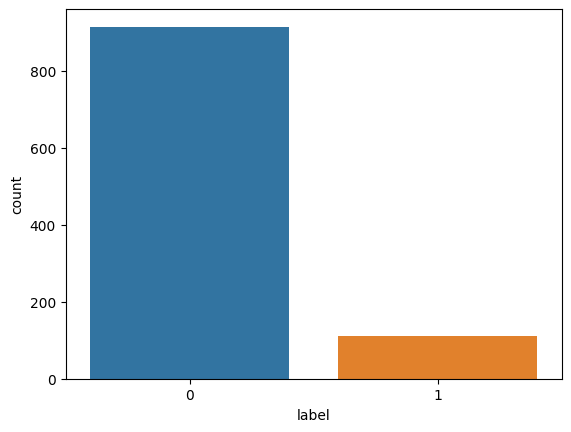

In [235]:
#Barplot for label
sns.barplot(x=y.value_counts().index, y=y.value_counts())

## SINCE THE DATASET IS AN "IMBALANCED DATASET" WE NEED TO TREAT THIS IMBALANCE DATASET ACCORDINGLY BEFORE BUILDING THE MODEL

# SPLITTING THE DATASET INTO 80% TRAIN AND 20% TEST DATASET

In [236]:
#Splitting dataset into training and testing dataset
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state=3, stratify=y)

#HERE, THE 'stratify' PARAMETER IS GIVEN 'y' BECAUSE THE DATASET IS IMBALANCED

# EDA OF THE NUMERICAL FEATURES

In [237]:
#Getting all the numerical features 
X_train.select_dtypes(exclude='object').head(2)

,Ind_ID,CHILDREN,Annual_income,Birthday_count,Employed_days,Mobile_phone,Work_Phone,Phone,EMAIL_ID,Family_Members
656,5146034,0,157500.0,-17111.0,-4146,1,0,0,0,1
988,5051120,0,202500.0,-12725.0,-5006,1,0,0,0,2


In [238]:
#Checking Correlation of the Independent features with the target feature
mutual_info = mutual_info_classif(X_train.select_dtypes(exclude='object'), y_train, random_state=47)

mutual_info = pd.Series(mutual_info)
mutual_info.index = X_train.select_dtypes(exclude='object').columns
mutual_info.sort_values(ascending=False)

Birthday_count    0.056667
Employed_days     0.046685
Ind_ID            0.031727
CHILDREN          0.015428
EMAIL_ID          0.012975
Annual_income     0.012120
Phone             0.005610
Family_Members    0.003082
Mobile_phone      0.000000
Work_Phone        0.000000
dtype: float64

In [239]:
#Checking all the columns
X_train.columns

Index(['Ind_ID', 'GENDER', 'Car_Owner', 'Propert_Owner', 'CHILDREN',
       'Annual_income', 'Type_Income', 'EDUCATION', 'Marital_status',
       'Birthday_count', 'Employed_days', 'Mobile_phone', 'Work_Phone',
       'Phone', 'EMAIL_ID', 'Type_Occupation', 'Family_Members'],
      dtype='object')

In [240]:
#Dropping some features in training dataset having lesser mutual information values
X_train = X_train.drop(['Ind_ID', 'Mobile_phone', 'Work_Phone','Phone', 'EMAIL_ID', 'Family_Members', 'Annual_income'], axis=1)
X_train.head(2)

,GENDER,Car_Owner,Propert_Owner,CHILDREN,Type_Income,EDUCATION,Marital_status,Birthday_count,Employed_days,Type_Occupation
656,M,N,Y,0,Working,Secondary / secondary special,Single / not married,-17111.0,-4146,Cooking staff
988,M,N,N,0,State servant,Higher education,Married,-12725.0,-5006,Core staff


In [241]:
#Dropping some features in testing dataset having lesser mutual information values
X_test = X_test.drop(['Ind_ID', 'Mobile_phone', 'Work_Phone','Phone', 'EMAIL_ID', 'Family_Members', 'Annual_income'], axis=1)
X_test.head(2)

,GENDER,Car_Owner,Propert_Owner,CHILDREN,Type_Income,EDUCATION,Marital_status,Birthday_count,Employed_days,Type_Occupation
838,F,N,Y,1,State servant,Incomplete higher,Civil marriage,-10926.0,-3570,Secretaries
698,M,N,N,0,Working,Higher education,Married,-13484.0,-2417,High skill tech staff


## With the above descriptive data let us explore all the features to understand the dataspread 

# Univariate analysis of the numerical features

In [242]:
#SELECTING ALL THE NUMERICAL FEATURES
X_train.select_dtypes(exclude='object').head(2) 

,CHILDREN,Birthday_count,Employed_days
656,0,-17111.0,-4146
988,0,-12725.0,-5006


In [243]:
#CHECKING THE VALUE COUNTS OF THE 'CHILDREN' COLUMN

X_train['CHILDREN'].value_counts()

CHILDREN
0    534
1    195
2     81
3      9
4      1
Name: count, dtype: int64

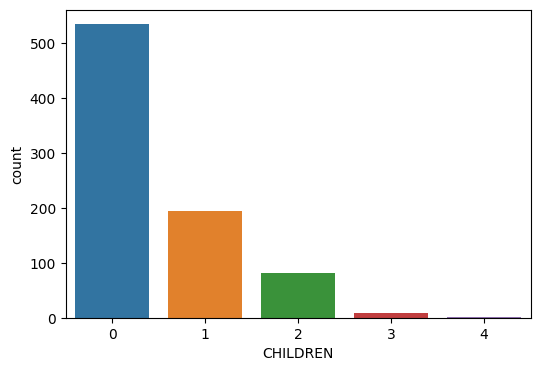

In [244]:
#BARPLOT OF THE 'CHILDREN' COLUMN SHOWING THE FREQUENCIES OF THE UNIQUE VALUES

plt.figure(figsize=(6,4))
sns.barplot(x = (X_train['CHILDREN'].value_counts()).index,  y = X_train['CHILDREN'].value_counts())
plt.show()

#THE 'CHILDREN' COLUMN CONTAINS AN OUTLIER AND IT IS AN OUTLIER BY MISTAKE. SO, IT CAN BE REPLACE WITH THE MEDIAN

In [245]:
#Handling the outlier of the children feature
X_train['CHILDREN'] = X_train['CHILDREN'].apply(lambda x: X_train['CHILDREN'].median() if x == 14 else x)

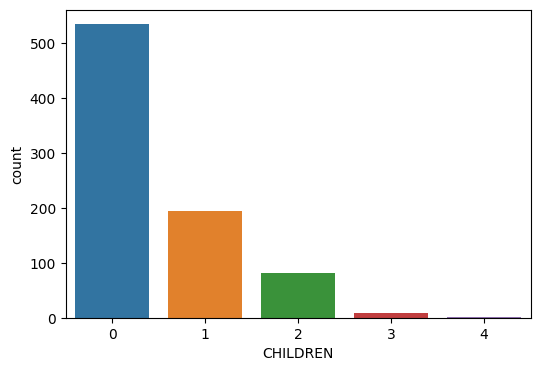

In [246]:
#BARPLOT OF THE 'CHILDREN' COLUMN SHOWING THE FREQUENCIES OF THE UNIQUE VALUES AFTER REMOVING OUTLIERS

plt.figure(figsize=(6,4))
sns.barplot(x = (X_train['CHILDREN'].value_counts()).index,  y = X_train['CHILDREN'].value_counts())
plt.show()

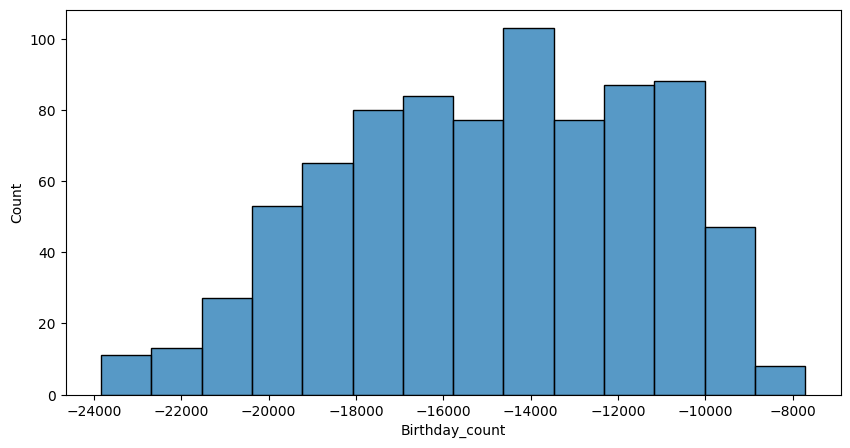

In [247]:
#HISTOGRAM OF THE 'Birthday_count' COLUMN

plt.figure(figsize=(10,5))
sns.histplot(X_train['Birthday_count'])
plt.show()

#IT IS EVIDENT FROM THE DISTRIBUTION THAT THE Birthday_count' COLUMN CONTAINS NO OUTLIERS AND HENCE NO TREATMENT IS NEEDED

In [248]:
#MAKING NEGATIVE VALUE OF 'Birthday_count' COLUMN TO POSITIVE VALUES AND CONVERTING DAYS TO THE AGE. 

X_train['Birthday_count'] = X_train['Birthday_count'].apply(lambda x: -x)

X_test['Birthday_count'] = X_test['Birthday_count'].apply(lambda x: -x)

X_train.head(2)

,GENDER,Car_Owner,Propert_Owner,CHILDREN,Type_Income,EDUCATION,Marital_status,Birthday_count,Employed_days,Type_Occupation
656,M,N,Y,0,Working,Secondary / secondary special,Single / not married,17111.0,-4146,Cooking staff
988,M,N,N,0,State servant,Higher education,Married,12725.0,-5006,Core staff


<Axes: xlabel='Employed_days'>

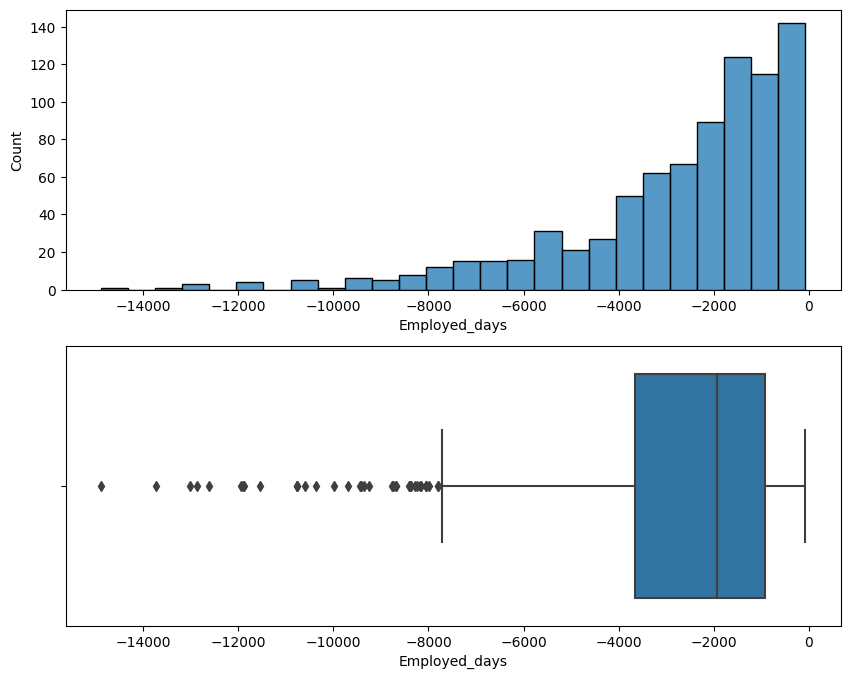

In [249]:
#HISTOGRAM OF THE 'Employed_days' COLUMN
fig, axes = plt.subplots(nrows=2, figsize=(10,8), sharex=False, sharey=False)
sns.histplot(X_train['Employed_days'], ax= axes[0])
sns.boxplot(x=X_train['Employed_days'], ax= axes[1])

#THE GRAPH CLEARLY SHOWS THAT THERE ARE SO MANY OUTLIERS IN THE 'Employed_days' COLUMN

#MOST OF THE VALUES ARE NEGATIVE AND ALL THE OUTLIERS ARE POSITIVE

In [250]:
#CHECKING THE 5 POINT SUMMARY
X_train['Employed_days'].describe()

count      820.000000
mean     -2716.600000
std       2441.341637
min     -14887.000000
25%      -3661.500000
50%      -1935.000000
75%       -931.000000
max        -73.000000
Name: Employed_days, dtype: float64

In [251]:
#SINCE THE POSITIVE VALUE OF THE 'Employed_days' COLUMN ARE THE UNEMPLOYED NUMBER OF DAYS, WE CAN ASSIGN ALL THE POSITIVE
#VALUES AS ZERO(0).

#CUSTOM TRANSFORMER TO ASSIGN THE POSITIVE VALUES OF 'Employed_days' COLUMN TO 0(ZERO)

X_train['Employed_days'] = X_train['Employed_days'].apply(lambda x: 0 if x>0 else -x)

X_test['Employed_days'] = X_test['Employed_days'].apply(lambda x: 0 if x>0 else -x)

X_train.head(2)

,GENDER,Car_Owner,Propert_Owner,CHILDREN,Type_Income,EDUCATION,Marital_status,Birthday_count,Employed_days,Type_Occupation
656,M,N,Y,0,Working,Secondary / secondary special,Single / not married,17111.0,4146,Cooking staff
988,M,N,N,0,State servant,Higher education,Married,12725.0,5006,Core staff


In [252]:
#CHECKING THE 5 POINT SUMMARY
X_train['Employed_days'].describe()

count      820.000000
mean      2716.600000
std       2441.341637
min         73.000000
25%        931.000000
50%       1935.000000
75%       3661.500000
max      14887.000000
Name: Employed_days, dtype: float64

<Axes: xlabel='Employed_days'>

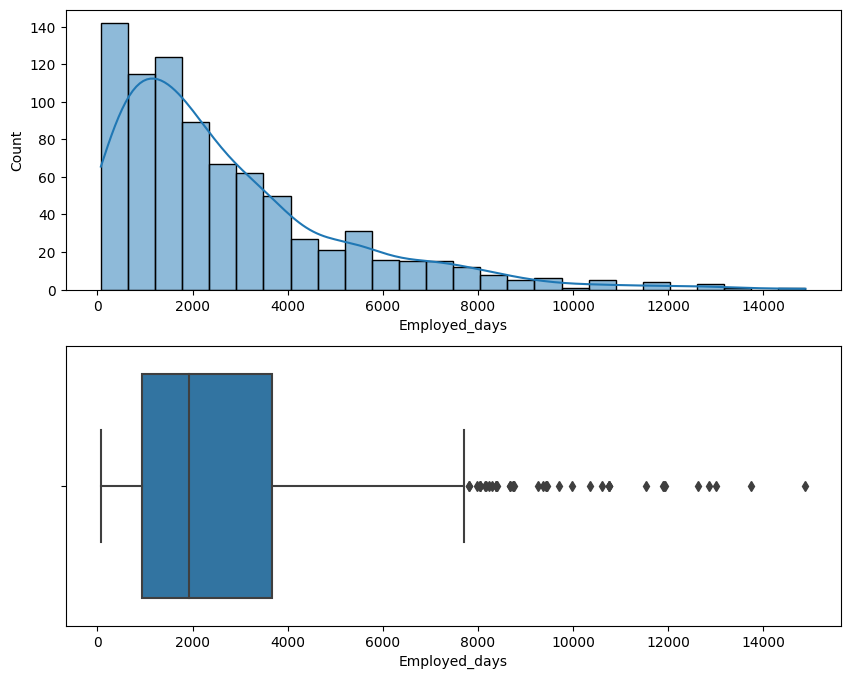

In [253]:
#HISTOGRAM OF THE 'Employed_days' COLUMN
fig, axes = plt.subplots(nrows=2, figsize=(10,8), sharex=False, sharey=False)
sns.histplot(X_train['Employed_days'], kde=True,ax= axes[0])
sns.boxplot(x=X_train['Employed_days'], ax= axes[1])

In [254]:
#Log transformation of the employed days feature
X_train['Employed_days'] = np.log(X_train['Employed_days'])

<Axes: xlabel='Employed_days'>

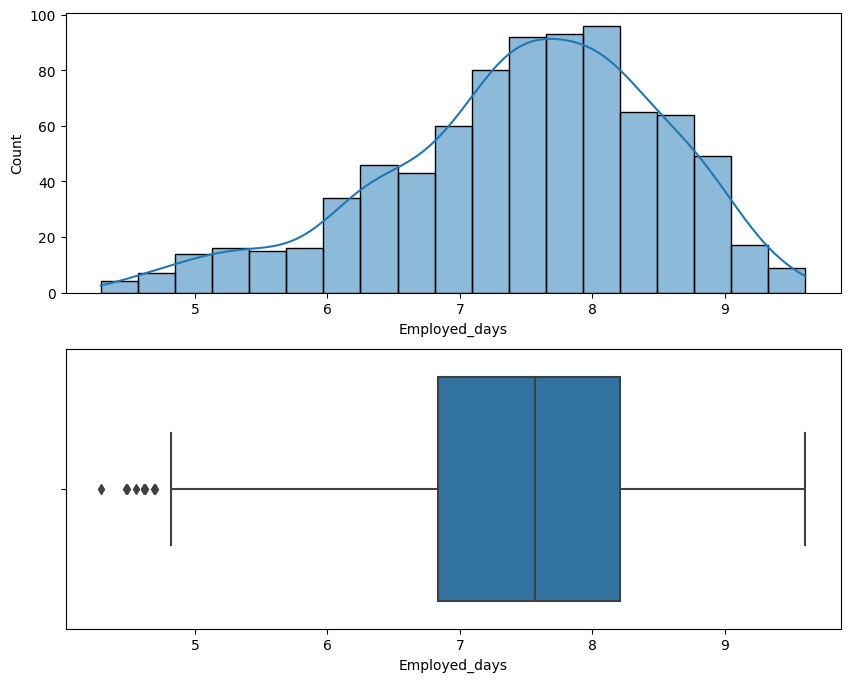

In [255]:
#HISTOGRAM OF THE 'Employed_days' COLUMN
fig, axes = plt.subplots(nrows=2, figsize=(10,8), sharex=False, sharey=False)
sns.histplot(X_train['Employed_days'], kde=True,ax= axes[0])
sns.boxplot(x=X_train['Employed_days'], ax= axes[1])

In [256]:
#Dealing the outliers of the Employed days feautre
q1 = X_train['Employed_days'].quantile(0.25)
q3 = X_train['Employed_days'].quantile(0.75)
median = X_train['Employed_days'].median()
IQR = q3 - q1

lower_limit = q1 - (1.5*IQR)
upper_limit = q3 + (1.5*IQR)

X_train['Employed_days'] = X_train['Employed_days'].apply(lambda x: lower_limit if x<lower_limit else upper_limit if x>upper_limit else x)


<Axes: xlabel='Employed_days'>

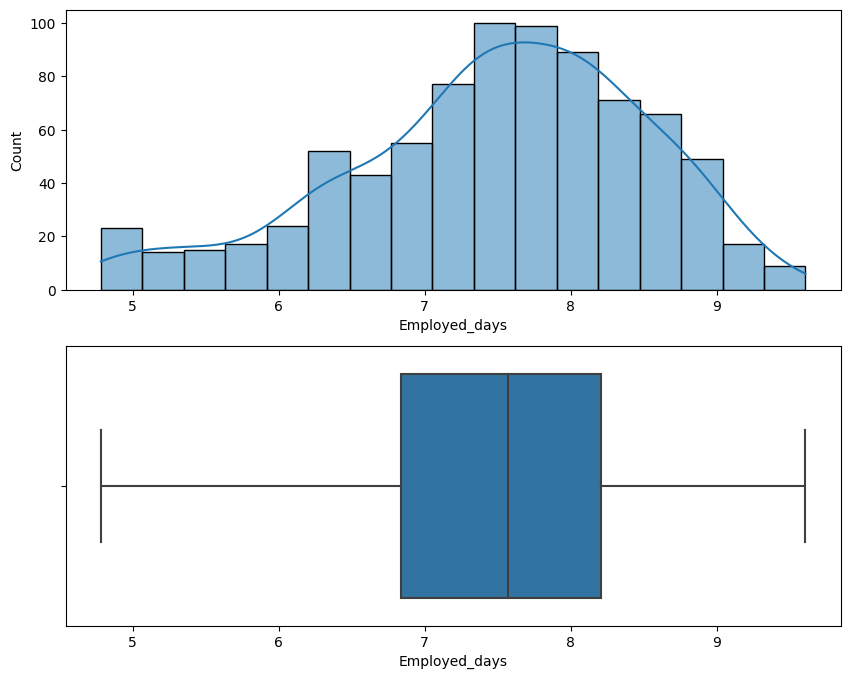

In [257]:
#HISTOGRAM OF THE 'Employed_days' COLUMN
fig, axes = plt.subplots(nrows=2, figsize=(10,8), sharex=False, sharey=False)
sns.histplot(X_train['Employed_days'], kde=True,ax= axes[0])
sns.boxplot(x=X_train['Employed_days'], ax= axes[1])

# Bivariate analysis of the numerical features with the target variable

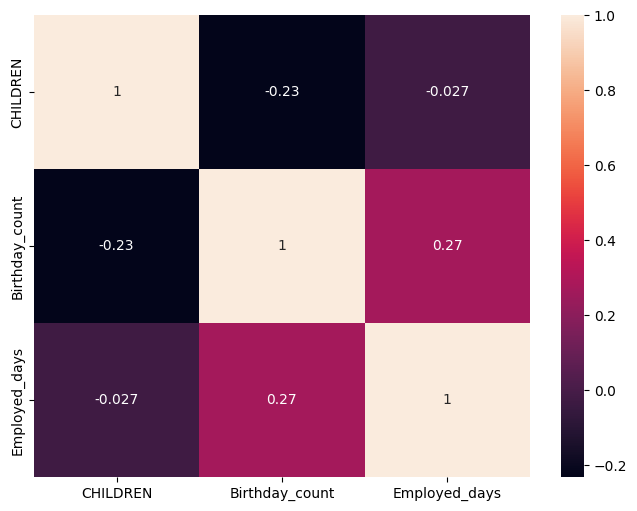

In [258]:
# Checking Correlationship among the continuous features
correlations = X_train.select_dtypes(exclude='object').corr()

plt.figure(figsize=(8,6))
sns.heatmap(correlations, annot=True)
plt.show()

# EDA OF THE CATEGORICAL FEATURES

## Checking the correlations of the independent categorical features with the target feature

In [259]:
#The categorical independent features
X_train.select_dtypes('object').head(2)

,GENDER,Car_Owner,Propert_Owner,Type_Income,EDUCATION,Marital_status,Type_Occupation
656,M,N,Y,Working,Secondary / secondary special,Single / not married,Cooking staff
988,M,N,N,State servant,Higher education,Married,Core staff


In [260]:
#Importing and initializing label encoder library 
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [261]:
#Label encoding all the objects type features
for col in X_train.select_dtypes('object').columns:
    X_train[col] = le.fit_transform(X_train[col])
    X_test[col] = le.transform(X_test[col])
X_train.head(2)

,GENDER,Car_Owner,Propert_Owner,CHILDREN,Type_Income,EDUCATION,Marital_status,Birthday_count,Employed_days,Type_Occupation
656,1,0,1,0,3,3,3,17111.0,8.329899,2
988,1,0,0,0,2,0,1,12725.0,8.518392,3


In [262]:
X_test.head(2)

,GENDER,Car_Owner,Propert_Owner,CHILDREN,Type_Income,EDUCATION,Marital_status,Birthday_count,Employed_days,Type_Occupation
838,0,0,1,1,2,1,0,10926.0,3570,15
698,1,0,0,0,3,0,1,13484.0,2417,6


In [263]:
#Getting all the columns
X_train.columns

Index(['GENDER', 'Car_Owner', 'Propert_Owner', 'CHILDREN', 'Type_Income',
       'EDUCATION', 'Marital_status', 'Birthday_count', 'Employed_days',
       'Type_Occupation'],
      dtype='object')

In [264]:
cat_columns = ['GENDER', 'Car_Owner', 'Propert_Owner', 'Type_Income','EDUCATION', 'Marital_status','Type_Occupation']

In [265]:
#Calculating the mutual information gain values of the categorical features with the target feature
mutual_info = mutual_info_classif(X_train[cat_columns], y_train, random_state=1)

mutual_info = pd.Series(mutual_info)
mutual_info.index = cat_columns
mutual_info.sort_values(ascending=False)

Type_Occupation    0.006495
Type_Income        0.004493
GENDER             0.000000
Car_Owner          0.000000
Propert_Owner      0.000000
EDUCATION          0.000000
Marital_status     0.000000
dtype: float64

In [266]:
X_train.head(2)

,GENDER,Car_Owner,Propert_Owner,CHILDREN,Type_Income,EDUCATION,Marital_status,Birthday_count,Employed_days,Type_Occupation
656,1,0,1,0,3,3,3,17111.0,8.329899,2
988,1,0,0,0,2,0,1,12725.0,8.518392,3


In [267]:
#Dropping the feature having lesser mutual information gain value for the training dataset
X_train = X_train.drop([ 'Car_Owner', 'Propert_Owner', 'EDUCATION', 'Marital_status'], axis=1)
X_train.head(2)

,GENDER,CHILDREN,Type_Income,Birthday_count,Employed_days,Type_Occupation
656,1,0,3,17111.0,8.329899,2
988,1,0,2,12725.0,8.518392,3


In [268]:
#Dropping the feature having lesser mutual information gain value for the testing dataset
X_test = X_test.drop([ 'Car_Owner', 'Propert_Owner', 'EDUCATION', 'Marital_status'], axis=1)
X_test.head(2)

,GENDER,CHILDREN,Type_Income,Birthday_count,Employed_days,Type_Occupation
838,0,1,2,10926.0,3570,15
698,1,0,3,13484.0,2417,6


# Univariate analysis of the categorical features

In [269]:
X_train.head(2)

,GENDER,CHILDREN,Type_Income,Birthday_count,Employed_days,Type_Occupation
656,1,0,3,17111.0,8.329899,2
988,1,0,2,12725.0,8.518392,3


In [270]:
X_train['GENDER'].value_counts()

GENDER
0    481
1    339
Name: count, dtype: int64

<Axes: xlabel='GENDER', ylabel='count'>

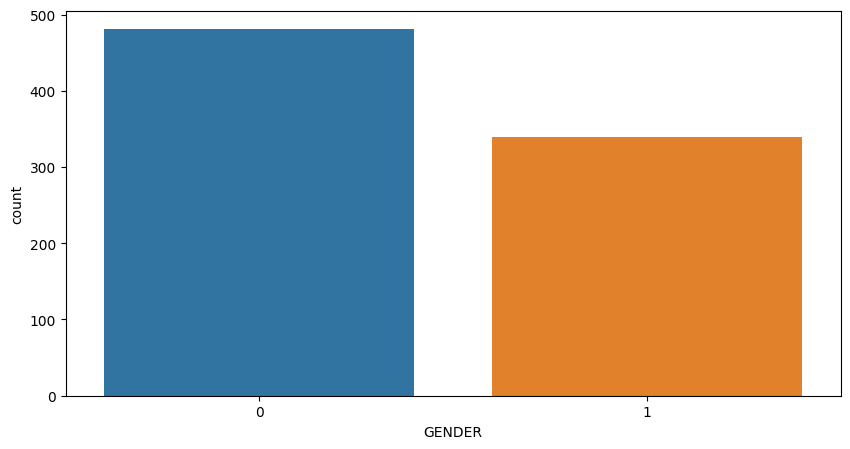

In [271]:
#BARPLOT OF THE 'GENDER' COLUMN

plt.figure(figsize=(10,5))
sns.barplot(x=(X_train['GENDER'].value_counts()).index, y=(X_train[['GENDER']].value_counts()))

In [272]:
X_train['Type_Income'].value_counts()

Type_Income
3    513
0    220
2     82
1      5
Name: count, dtype: int64

<Axes: xlabel='Type_Income', ylabel='count'>

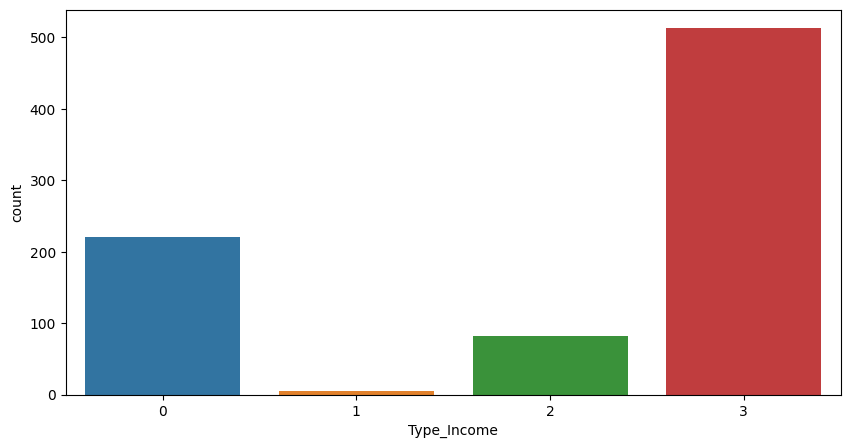

In [273]:
#BARPLOT OF THE 'Type_Income' COLUMN

plt.figure(figsize=(10,5))
sns.barplot(x=(X_train['Type_Income'].value_counts()).index, y=(X_train[['Type_Income']].value_counts()))

In [274]:
X_train['Type_Occupation'].value_counts()

Type_Occupation
8     209
3     137
10     99
14     89
4      71
6      52
0      40
11     39
16     21
12     14
2      14
1      13
9       7
15      6
5       3
13      2
7       2
17      2
Name: count, dtype: int64

<Axes: xlabel='count', ylabel='Type_Occupation'>

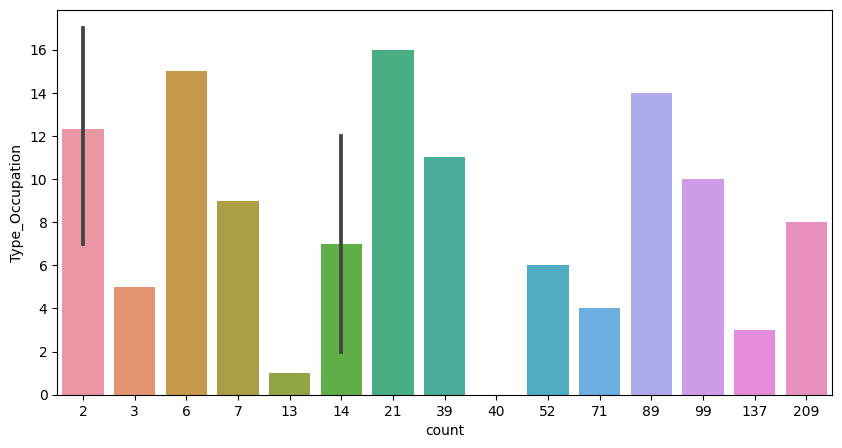

In [275]:
#BARPLOT OF THE 'Type_Occupation' COLUMN

plt.figure(figsize=(10,5))
sns.barplot(x=(X_train[['Type_Occupation']].value_counts()), y=(X_train['Type_Occupation'].value_counts()).index)

# Classification model building using the selected features

In [276]:
ss = StandardScaler()

In [277]:
#Scaling the training and testing dataset
scaled_xtrain = ss.fit_transform(X_train)
scaled_xtest = ss.transform(X_test)

In [278]:
#Pipelines to transform and handle the imbalanced training dataset

pipe = imbpipeline([
    ('smk', SMOTENC(categorical_features=[0, 2, 5], sampling_strategy = 1)) ])  #Handling imbalanced data


In [279]:
#Oversampling the dataset
sampled_xtrain = pipe.fit_resample(scaled_xtrain, y_train)

In [280]:
#INITIALIZE A LIST OF 4 CLASSIFIERS

lr = LogisticRegression()
dt = DecisionTreeClassifier()
svm = SVC(C=150, gamma=0.1, kernel='rbf', probability=True)
rf = RandomForestClassifier(n_estimators = 250, criterion='entropy',max_depth = 3)
xgb = XGBClassifier(learning_rate =1, n_estimators=250)

In [281]:
#INITIALIZE THE XGB CLASSIFIER

xgb = XGBClassifier(learning_rate =0.1, n_estimators=150)

In [282]:
#Finding the best classifier

classifier = xgb

clf_pipe = imbpipeline([ 
('clf', classifier) ])
 
clf_pipe.fit(sampled_xtrain[0], sampled_xtrain[1])
predicted_val = clf_pipe.predict(scaled_xtest)
pres_result = accuracy_score(y_test, predicted_val)

print('Accuracy Score of XGBoost Classifier model =', pres_result)


Precision Score of XGBoost Classifier model = 0.8926829268292683


## XGBOOST CLASSIFIER IS CHOOSEN.

In [283]:
#Cross validation of the XG-Boost Classifier

cross_val_score(xgb, sampled_xtrain[0], sampled_xtrain[1], scoring = 'accuracy')

array([0.83617747, 0.90784983, 0.9112628 , 0.9112628 , 0.90753425])

## Final training the XG-Boost classifier with the best parameters

In [284]:
#TRAINING THE SVM CLASSIFICATION ALGORITHM

credit_classifier = xgb.fit(sampled_xtrain[0], sampled_xtrain[1])

In [285]:
#PREDICTING USING THE TRAINED MODEL

predicted = credit_classifier.predict(X_test)

In [286]:
accuracy_score(y_test, predicted)

0.8926829268292683

In [287]:
print('The Accuracy Score of the Classification Model is ', accuracy_score(y_test,predicted) ) 


The Accuracy Score of the Classification Model is  0.8926829268292683


## ROC Curve

In [288]:
#Prediction probability

model_proba = credit_classifier.predict_proba(X_test)[:,1]

In [289]:
#Getting the values from the roc curve

fpr, tpr, threshold = roc_curve(y_test, model_proba)

In [290]:
#Making a dataframe for the values(fpr, tpr, threshold) of the roc curve

roc_df = pd.DataFrame(zip(fpr, tpr, threshold), columns=['FPR', 'TPR', 'THRES_V'])
roc_df

,FPR,TPR,THRES_V
0,0.000000,0.000000,inf
1,0.005464,0.000000,0.050702
2,0.032787,0.045455,0.046191
3,0.043716,0.045455,0.046087
4,0.081967,0.045455,0.043767
5,0.098361,0.090909,0.025192
6,0.142077,0.090909,0.023842
7,0.169399,0.136364,0.022443
8,0.229508,0.136364,0.021237
9,0.267760,0.227273,0.012103


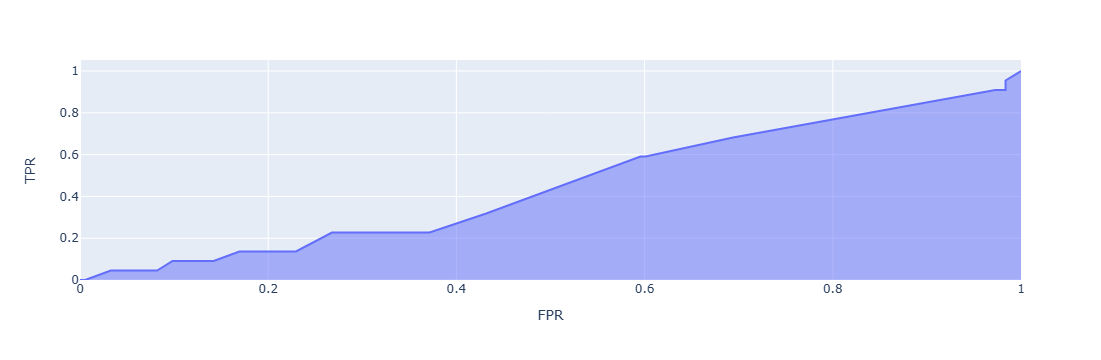

In [291]:
# roc curve for the classifier model

px.area(roc_df,x='FPR', y='TPR', hover_data=['THRES_V'])

In [292]:
#Area under the roc curve

roc_auc_score(y_test, model_proba)

0.45069547938400395

# Conclusion 

## Out of the 17 columns, 6 columns('GENDER','CHILDREN', 'Type_Income', 'Birthday_count','Employed_days','Type_Occupation') are found important. The XG Boost Classifier gives the highest accuracy score of around 90% and having ROC AUC SCORE of 50%.